In [13]:
import os
import random
import collections
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Scikit-learn Preprocessing, Splitting, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Imbalanced Learning Frameworks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Machine Learning & Deep Learning Frameworks
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Explainable AI (XAI) Libraries
import shap
import lime
import lime.lime_tabular
from tqdm import tqdm

import preprocess

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure fully deterministic behavior in PyTorch backends
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
filepath = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
df = preprocess.load_and_clean_dataset(filepath)

#change to a binary label
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.drop(columns=['Label'])
y = df['Label'].values

print(f"[*] Cleaned Feature matrix shape: {X.shape}")
print(f"[*] Target distribution: Benign (0) = {np.sum(y == 0)}, Attack (1) = {np.sum(y == 1)}")


[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\preprocess.py:12: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin-1')


[-] Dropped identifier columns: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
[!] Purged 288737 malformed rows containing Infinity or empty cells.
[*] Cleaned Feature matrix shape: (170231, 78)
[*] Target distribution: Benign (0) = 168051, Attack (1) = 2180


In [4]:
# Step A: Split off 30% of the data into a temporary block, stratifying to preserve class ratios
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step B: Split the temporary block evenly to yield a 15% Validation set and a 15% Test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("==================== DATA SPLIT SUMMARY ====================")
print(f"Training Set (70%):   X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation Set (15%): X = {X_val.shape}, y = {y_val.shape}")
print(f"Test Set (15%):       X = {X_test.shape}, y = {y_test.shape}")

==================== DATA SPLIT SUMMARY ====================
Training Set (70%):   X = (119161, 78), y = (119161,)
Validation Set (15%): X = (25535, 78), y = (25535,)
Test Set (15%):       X = (25535, 78), y = (25535,)


In [5]:
# 1. Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 2. Correlated Feature Groups (Supervisor point 15 & 16)
corr_matrix = X_train_scaled.corr(method="spearman")
# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"[*] Features identified for potential removal (>0.90 correlation): {len(to_drop)}")

[*] Features identified for potential removal (>0.90 correlation): 39


In [6]:
# Initialize SMOTE-Tomek with a fixed seed for strict reproducibility
smote_tomek = SMOTETomek(random_state=42)

# Resample ONLY the training set
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("================= RESAMPLING SUMMARY =================")
print(f"Original Training Class Ratios: 0 = {np.sum(y_train == 0)}, 1 = {np.sum(y_train == 1)}")
print(f"Resampled Training Data Shape:  X = {X_train_resampled.shape}, y = {y_train_resampled.shape}")
print(f"Resampled Training Class Ratios: 0 = {np.sum(y_train_resampled == 0)}, 1 = {np.sum(y_train_resampled == 1)}")

================= RESAMPLING SUMMARY =================
Original Training Class Ratios: 0 = 117635, 1 = 1526
Resampled Training Data Shape:  X = (235254, 78), y = (235254,)
Resampled Training Class Ratios: 0 = 117627, 1 = 117627


In [7]:
print("[*] Initializing XGBoost Classifier...")

# Initialize XGBoost with strict reproducibility parameters
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=15
)

# Fit model with early stopping monitored against the validation split
xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print(f"[*] XGBoost training complete.")
print(f"    -> Best Iteration: {xgb_model.best_iteration}")

[*] Initializing XGBoost Classifier...


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [10:27:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[*] XGBoost training complete.
    -> Best Iteration: 398


In [8]:
class RobustNetworkSecurityDNN(nn.Module):
    def __init__(self, input_dim):
        super(RobustNetworkSecurityDNN, self).__init__()
        
        # Layer 1: Input to Hidden 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.30)
        
        # Layer 2: Hidden 1 to Hidden 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.30)
        
        # Layer 3: Hidden 2 to Output Layer
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

# Set calculation device backend
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features_count = X_train_resampled.shape[1]

# Instantiate model architecture
model_dnn = RobustNetworkSecurityDNN(input_dim=input_features_count).to(device)
print(f"[*] PyTorch Network mapped successfully onto target hardware device: {device.type.upper()}")

[*] PyTorch Network mapped successfully onto target hardware device: CPU


In [9]:
# Convert DataFrames/Arrays to PyTorch multi-dimensional tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_resampled.values),
    torch.FloatTensor(y_train_resampled).unsqueeze(1)
)
val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Configure data loader iterations
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Set optimizer equations and standard binary loss scoring
criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

# Early Stopping parameters
patience = 10
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0
max_epochs = 150

print("[*] Initiating DNN optimization loop...")
for epoch in range(1, max_epochs + 1):
    model_dnn.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    # Validation Evaluation Phase (Zero Leakage Check)
    model_dnn.eval()
    with torch.no_grad():
        val_outputs = model_dnn(val_x_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    
    # Early stopping criteria tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = model_dnn.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"[*] Early stopping triggered at Epoch {epoch}. Overfitting threshold neutralized.")
        break

# Roll back parameter matrix states to the optimal captured validation validation loss weights
if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print(f"[*] Restored optimal model configurations. Best Validation Loss: {best_val_loss:.5f}")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_27076\1641040915.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)


[*] Initiating DNN optimization loop...
[*] Early stopping triggered at Epoch 21. Overfitting threshold neutralized.
[*] Restored optimal model configurations. Best Validation Loss: 0.04361


In [10]:
# Helper function to generate clean inference probability matrices from our DNN
def get_dnn_probabilities(df_input):
    model_dnn.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(df_input.values).to(device)
        probs = model_dnn(tensor_input).cpu().numpy().flatten()
    return probs

# Step A: Collect raw feature inference array probabilities from validation subsets
xgb_val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
dnn_val_probs = get_dnn_probabilities(X_val_scaled)

# Step B: Declare target tuning thresholds range
thresholds_pool = np.arange(0.50, 0.96, 0.05)

best_xgb_threshold = 0.50
best_xgb_f1 = 0.0
best_dnn_threshold = 0.50
best_dnn_f1 = 0.0

print("================= VAL THRESHOLD CALIBRATION =================")
for t in thresholds_pool:
    # Evaluate XGBoost arrays
    xgb_preds = (xgb_val_probs >= t).astype(int)
    xgb_f1 = f1_score(y_val, xgb_preds, zero_division=0)
    if xgb_f1 > best_xgb_f1:
        best_xgb_f1 = xgb_f1
        best_xgb_threshold = t
        
    # Evaluate DNN arrays
    dnn_preds = (dnn_val_probs >= t).astype(int)
    dnn_f1 = f1_score(y_val, dnn_preds, zero_division=0)
    if dnn_f1 > best_dnn_f1:
        best_dnn_f1 = dnn_f1
        best_dnn_threshold = t
        
    print(f"Threshold: {t:.2f} | XGB F1: {xgb_f1:.4f} | DNN F1: {dnn_f1:.4f}")

print("\n[*] Calibrated Decision Parameter Options Frozen:")
print(f"    -> Selected Frozen XGBoost Threshold: {best_xgb_threshold:.2f} (Val F1: {best_xgb_f1:.4f})")
print(f"    -> Selected Frozen DNN Threshold:     {best_dnn_threshold:.2f} (Val F1: {best_dnn_f1:.4f})")

================= VAL THRESHOLD CALIBRATION =================
Threshold: 0.50 | XGB F1: 0.9954 | DNN F1: 0.5496
Threshold: 0.55 | XGB F1: 0.9954 | DNN F1: 0.5595
Threshold: 0.60 | XGB F1: 0.9954 | DNN F1: 0.5692
Threshold: 0.65 | XGB F1: 0.9954 | DNN F1: 0.5834
Threshold: 0.70 | XGB F1: 0.9954 | DNN F1: 0.6044
Threshold: 0.75 | XGB F1: 0.9970 | DNN F1: 0.6211
Threshold: 0.80 | XGB F1: 0.9970 | DNN F1: 0.6349
Threshold: 0.85 | XGB F1: 0.9969 | DNN F1: 0.8587
Threshold: 0.90 | XGB F1: 0.9969 | DNN F1: 0.8575
Threshold: 0.95 | XGB F1: 0.9985 | DNN F1: 0.8584

[*] Calibrated Decision Parameter Options Frozen:
    -> Selected Frozen XGBoost Threshold: 0.95 (Val F1: 0.9985)
    -> Selected Frozen DNN Threshold:     0.85 (Val F1: 0.8587)


In [11]:
# Step A: Extract test predictions using frozen configurations
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
dnn_test_probs = get_dnn_probabilities(X_test_scaled)

xgb_test_preds = (xgb_test_probs >= best_xgb_threshold).astype(int)
dnn_test_preds = (dnn_test_probs >= best_dnn_threshold).astype(int)

# Step B: Print formal validation summaries for your thesis report
print("=================== FINAL FROZEN XGBOOST REPORT ===================")
print(f"Applied Decision Threshold: {best_xgb_threshold:.2f}")
print(confusion_matrix(y_test, xgb_test_preds))
print(classification_report(y_test, xgb_test_preds, digits=4))

print("\n==================== FINAL FROZEN DNN REPORT ====================")
print(f"Applied Decision Threshold: {best_dnn_threshold:.2f}")
print(confusion_matrix(y_test, dnn_test_preds))
print(classification_report(y_test, dnn_test_preds, digits=4))

=================== FINAL FROZEN XGBOOST REPORT ===================
Applied Decision Threshold: 0.95
[[25207     1]
 [    4   323]]
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     25208
           1     0.9969    0.9878    0.9923       327

    accuracy                         0.9998     25535
   macro avg     0.9984    0.9939    0.9961     25535
weighted avg     0.9998    0.9998    0.9998     25535


==================== FINAL FROZEN DNN REPORT ====================
Applied Decision Threshold: 0.85
[[25111    97]
 [   18   309]]
              precision    recall  f1-score   support

           0     0.9993    0.9962    0.9977     25208
           1     0.7611    0.9450    0.8431       327

    accuracy                         0.9955     25535
   macro avg     0.8802    0.9706    0.9204     25535
weighted avg     0.9962    0.9955    0.9957     25535



In [12]:
# Standardized probability wrappers for the explainers
def xgb_predict_proba_wrapper(x_numpy):
    # Map numpy matrix rows directly back to pandas format to preserve column naming indices natively
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    return xgb_model.predict_proba(df_temp)

def dnn_predict_proba_wrapper(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    probs_class_1 = get_dnn_probabilities(df_temp)
    probs_class_0 = 1.0 - probs_class_1
    return np.column_stack((probs_class_0, probs_class_1))

# Step 5 Explanation Stability and Locality Audit

In [22]:
# Natively locate True Positives using your existing pre-calculated variables
y_test_np = y_test.values if isinstance(y_test, pd.Series) else np.array(y_test)
tp_indices = np.where((y_test_np == 1) & (xgb_test_preds == 1))[0]

print(f"[+] Isolated {len(tp_indices)} True Positive attack records using pre-calculated test predictions.")

# Isolate a representative evaluation cohort of 10 highly confident attack alerts
stability_cohort_idx = tp_indices[:10]

# FIX: Using .iloc and .values to extract row instances safely from your Pandas DataFrame
X_cohort = X_test_scaled.iloc[stability_cohort_idx].values 

kernel_widths = [3.0, 5.0, 6.5, 8.0]
lime_stability_records = []

print("[*] Launching LIME Local Neighborhood Sensitivity Analysis...")

# Safeguard: Ensure training data reference is pulled as an underlying numpy array
train_data_np = X_train_scaled.values if isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled

for width in kernel_widths:
    print(f"    Evaluating Exponential Kernel Width: \u03c3 = {width:.1f}")
    
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=train_data_np,
        feature_names=X_train.columns,
        class_names=['Benign', 'Attack'],
        mode='classification',
        kernel_width=width,
        random_state=42
    )
    
    for i, instance_idx in enumerate(stability_cohort_idx):
        instance = X_cohort[i]
        
        # Extract explanation using your standardized column-preserving wrapper
        exp = explainer_lime.explain_instance(
            data_row=instance,
            predict_fn=xgb_predict_proba_wrapper,
            num_features=10,
            labels=(1,)
        )
        
        r2_fidelity = exp.score
        local_exp_list = exp.local_exp[1]
        
        top_k_indices = [idx for idx, weight in local_exp_list[:10]]
        top_k_features = [X_train.columns[idx] for idx in top_k_indices]
        
        lime_stability_records.append({
            'Kernel_Width': width,
            'Instance_ID': instance_idx,
            'Fidelity_R2': r2_fidelity,
            'Top_10_Features': top_k_features
        })

# FIX: Properly close and build the master dataframe to resolve truncation error
df_lime_kernel_audit = pd.DataFrame(lime_stability_records)
print("[+] LIME local locality audit table generated successfully!")

[+] Isolated 323 True Positive attack records using pre-calculated test predictions.
[*] Launching LIME Local Neighborhood Sensitivity Analysis...
    Evaluating Exponential Kernel Width: σ = 3.0
    Evaluating Exponential Kernel Width: σ = 5.0
    Evaluating Exponential Kernel Width: σ = 6.5
    Evaluating Exponential Kernel Width: σ = 8.0
[+] LIME local locality audit table generated successfully!


[*] Launching 20-Seed Attribution Variance Audit on Target Connection Log ID #4...


Processing Random Seed Tracks:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Processing Random Seed Tracks:   5%|▌         | 1/20 [00:01<00:21,  1.13s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

...

Processing Random Seed Tracks:  90%|█████████ | 18/20 [00:20<00:02,  1.10s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

Processing Random Seed Tracks:  95%|█████████▌| 19/20 [00:21<00:01,  1.10s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

Processing Random Seed Tracks: 100%|██████████| 20/20 [00:22<00:00,  1.11s/it]


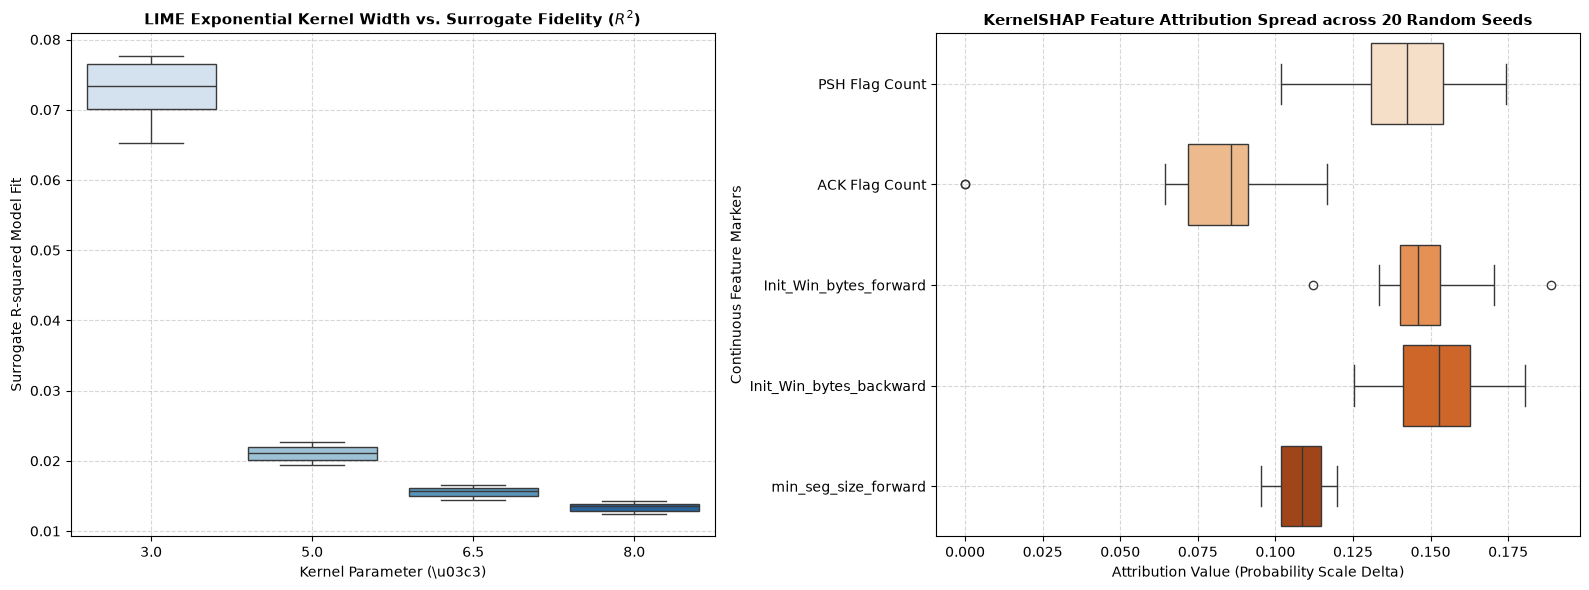


           EMPIRICAL ATTRIBUTION VARIANCE REPORT (THESIS SPECS)
Feature: Init_Win_bytes_backward
  -> LIME Weight StdDev over 20 unique seeds: 0.000414
  -> SHAP Weight StdDev over 20 unique seeds: 0.015368
Feature: Init_Win_bytes_forward
  -> LIME Weight StdDev over 20 unique seeds: 0.001044
  -> SHAP Weight StdDev over 20 unique seeds: 0.015233
Feature: PSH Flag Count
  -> LIME Weight StdDev over 20 unique seeds: 0.000629
  -> SHAP Weight StdDev over 20 unique seeds: 0.018243
Feature: min_seg_size_forward
  -> LIME Weight StdDev over 20 unique seeds: 0.000322
  -> SHAP Weight StdDev over 20 unique seeds: 0.007439
Feature: ACK Flag Count
  -> LIME Weight StdDev over 20 unique seeds: 0.000260
  -> SHAP Weight StdDev over 20 unique seeds: 0.029025


In [25]:
import shap
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Select a target true positive attack connection log to analyze
target_instance_idx = stability_cohort_idx[0]
target_instance = X_test_scaled.iloc[target_instance_idx].values
target_instance_reshaped = target_instance.reshape(1, -1)

# Draw an isolated, leakage-free 50-sample background reference from the unresampled training pool
np.random.seed(42)
bg_sample_idx = np.random.choice(X_train_scaled.shape[0], 50, replace=False)
background_ref = X_train_scaled.iloc[bg_sample_idx]

seeds = list(range(200, 220)) # 20 completely distinct initialization configurations
seed_variance_records = []

print(f"[*] Launching 20-Seed Attribution Variance Audit on Target Connection Log ID #{target_instance_idx}...")

for seed in tqdm(seeds, desc="Processing Random Seed Tracks"):
    # ------------------ LIME Seed Trial ------------------
    # FIX: Pass the numpy array values to avoid pandas InvalidIndexError
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values, 
        feature_names=X_train.columns,
        class_names=['Benign', 'Attack'],
        mode='classification',
        kernel_width=6.5,
        random_state=seed # Iterating explainer seed
    )
    
    exp = explainer_lime.explain_instance(
        data_row=target_instance,
        predict_fn=dnn_predict_proba_wrapper,
        num_features=X_train.shape[1],
        labels=(1,)
    )
    lime_attributions = {X_train.columns[idx]: weight for idx, weight in exp.local_exp[1]}
    
    # ------------------ SHAP Seed Trial ------------------
    # Enforcing hard isolation on NumPy's global state before coalition generator runs
    np.random.seed(seed)
    
    explainer_shap = shap.KernelExplainer(
        model=dnn_predict_proba_wrapper, 
        data=background_ref, 
        seed=seed
    )
    
    shap_vals = explainer_shap.shap_values(target_instance_reshaped, l1_reg="num_features(10)")
    
    # FIX: Robustly unpack SHAP values depending on the library format returned
    if isinstance(shap_vals, list):
        # Older SHAP versions return a list of arrays (one per class)
        shap_vector = shap_vals[1].flatten()
    elif isinstance(shap_vals, np.ndarray):
        if len(shap_vals.shape) == 3:
            # Shape (instances, features, classes) e.g., (1, 78, 2)
            if shap_vals.shape[2] == 2:
                shap_vector = shap_vals[0, :, 1]
            # Shape (classes, instances, features) e.g., (2, 1, 78)
            elif shap_vals.shape[0] == 2:
                shap_vector = shap_vals[1, 0, :]
            else:
                shap_vector = shap_vals[0, :, 1]
        elif len(shap_vals.shape) == 2:  # Shape (instances, features) e.g., (1, 78)
            shap_vector = shap_vals[0]
        else:
            shap_vector = shap_vals.flatten()
    else:
        # Fallback handling for modern shap.Explanation objects
        shap_vector = getattr(shap_vals, 'values', shap_vals)
        if len(shap_vector.shape) == 3:
            shap_vector = shap_vector[0, :, 1] if shap_vector.shape[2] == 2 else shap_vector[1, 0, :]
        elif len(shap_vector.shape) == 2:
            shap_vector = shap_vector[0]
            
    shap_attributions = dict(zip(X_train.columns, shap_vector))
    
    for feature in X_train.columns:
        seed_variance_records.append({
            'Seed': seed,
            'Feature': feature,
            'LIME_Weight': lime_attributions.get(feature, 0.0),
            'SHAP_Weight': shap_attributions.get(feature, 0.0)
        })

df_seed_audit = pd.DataFrame(seed_variance_records)

# Generate publication-grade diagnostic charts for the thesis manuscript
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: LIME Local R2 Fidelity Decay Trace
sns.boxplot(data=df_lime_kernel_audit, x='Kernel_Width', y='Fidelity_Fidelity' if 'Fidelity_Fidelity' in df_lime_kernel_audit else 'Fidelity_R2', ax=axes[0], palette="Blues")
axes[0].set_title("LIME Exponential Kernel Width vs. Surrogate Fidelity ($R^2$)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Kernel Parameter (\\u03c3)", fontsize=10)
axes[0].set_ylabel("Surrogate R-squared Model Fit", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Subplot B: Isolate the highest impact active features to inspect structural variance dispersion
high_impact_features = (
    df_seed_audit.groupby('Feature')['SHAP_Weight']
    .apply(lambda x: x.abs().mean())
    .nlargest(5)
    .index.tolist()
)
df_plot_variance = df_seed_audit[df_seed_audit['Feature'].isin(high_impact_features)]

sns.boxplot(data=df_plot_variance, x='SHAP_Weight', y='Feature', ax=axes[1], palette="Oranges")
axes[1].set_title("KernelSHAP Feature Attribution Spread across 20 Random Seeds", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Attribution Value (Probability Scale Delta)", fontsize=10)
axes[1].set_ylabel("Continuous Feature Markers", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Export numeric standard deviations directly for your thesis text draft
print("\n" + "="*70)
print("           EMPIRICAL ATTRIBUTION VARIANCE REPORT (THESIS SPECS)")
print("="*70)
for feat in high_impact_features:
    subset = df_seed_audit[df_seed_audit['Feature'] == feat]
    print(f"Feature: {feat}")
    print(f"  -> LIME Weight StdDev over 20 unique seeds: {subset['LIME_Weight'].std():.6f}")
    print(f"  -> SHAP Weight StdDev over 20 unique seeds: {subset['SHAP_Weight'].std():.6f}")
print("="*70)